In [1]:
"""import requests
import time

stock_symbol = 'GOOGL'


def api_call(function, symbol):
    url = f'https://www.alphavantage.co/query?function={function}&symbol={symbol}&apikey=SLNN0RY99W9UB303'
    r = requests.get(url)
    data = r.text
    return data

def write_api_data_to_file(function, symbol):
    data = api_call(function, symbol)
    with open(f'{symbol}_{function}.json', 'w+') as f:
        f.write(data)

write_api_data_to_file('CASH_FLOW', stock_symbol)
time.sleep(6)
write_api_data_to_file('EARNINGS', stock_symbol)
time.sleep(6)
write_api_data_to_file('INCOME_STATEMENT', stock_symbol)
time.sleep(6)
write_api_data_to_file('BALANCE_SHEET', stock_symbol)"""

"import requests\nimport time\n\nstock_symbol = 'GOOGL'\n\n\ndef api_call(function, symbol):\n    url = f'https://www.alphavantage.co/query?function={function}&symbol={symbol}&apikey=SLNN0RY99W9UB303'\n    r = requests.get(url)\n    data = r.text\n    return data\n\ndef write_api_data_to_file(function, symbol):\n    data = api_call(function, symbol)\n    with open(f'{symbol}_{function}.json', 'w+') as f:\n        f.write(data)\n\nwrite_api_data_to_file('CASH_FLOW', stock_symbol)\ntime.sleep(6)\nwrite_api_data_to_file('EARNINGS', stock_symbol)\ntime.sleep(6)\nwrite_api_data_to_file('INCOME_STATEMENT', stock_symbol)\ntime.sleep(6)\nwrite_api_data_to_file('BALANCE_SHEET', stock_symbol)"

In [2]:
symbol = 'GOOGL'
"""
API_KEY = 'SLNN0RY99W9UB303'
import requests
import time
def download_price_json(symbol):
    url = f'https://www.alphavantage.co/query?function=TIME_SERIES_MONTHLY_ADJUSTED&symbol={symbol}&apikey={API_KEY}&datatype=json'
    r = requests.get(url)
    data = r.text
    with open(f'{symbol}_PRICE.json', 'w+') as f:
        f.write(data)
    # Alpha Vantage has strict rate limits
    time.sleep(12)

download_price_json(symbol)"""

"\nAPI_KEY = 'SLNN0RY99W9UB303'\nimport requests\nimport time\ndef download_price_json(symbol):\n    url = f'https://www.alphavantage.co/query?function=TIME_SERIES_MONTHLY_ADJUSTED&symbol={symbol}&apikey={API_KEY}&datatype=json'\n    r = requests.get(url)\n    data = r.text\n    with open(f'{symbol}_PRICE.json', 'w+') as f:\n        f.write(data)\n    # Alpha Vantage has strict rate limits\n    time.sleep(12)\n\ndownload_price_json(symbol)"

In [150]:
def load_price_json_to_df(symbol):
    import json, pandas as pd
    with open(f'{symbol}_PRICE.json') as f:
        data = json.load(f)

    ts = data['Monthly Adjusted Time Series']
    df = pd.DataFrame(ts).T
    df.index.name = 'fiscalDateEnding'
    df = df.reset_index()
    df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'])
    df['close'] = df['4. close'].astype(float)
    return df[['fiscalDateEnding', 'close']]

In [151]:
import pandas as pd
import json

def load_json_to_df(ticker,filename, key):
    with open(filename, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame(data[key])
    df['Ticker'] = ticker
    return df

In [152]:
def convert_columns_to_numeric(df, cols_to_exclude):
    cols_to_convert = df.columns.difference(cols_to_exclude)
    df[cols_to_convert] = df[cols_to_convert].apply(
        pd.to_numeric,
        errors='coerce'
    )
    return df

In [153]:
def filter_df_by_date(df, date_col, start_date, end_date):
    return df[(df[date_col] > pd.to_datetime(start_date)) & (df[date_col] < pd.to_datetime(end_date))]

In [154]:
def resample_and_interpolate(df, cols_to_interpolate=None):
    df_indexed = df.set_index('fiscalDateEnding')

    # Ensure datetime, sorted, and aligned to month start
    df_indexed.index = pd.to_datetime(df_indexed.index)
    df_indexed.index = df_indexed.index.to_period('M').to_timestamp()
    df_indexed = df_indexed.sort_index()
    #display(df_indexed.head())
    # Monthly range
    date_range = pd.date_range(
        start=df_indexed.index.min(),
        end=df_indexed.index.max(),
        freq='MS'
    )

    # Reindex
    df_monthly = df_indexed[cols_to_interpolate].reindex(date_range)

    # Count valid points
    valid_points = df_monthly.notna().sum().max()

    if valid_points >= 4:
        df_monthly = df_monthly.interpolate(
            method='spline',
            order=3,
            limit_area='inside'
        )
    else:
        df_monthly = df_monthly.interpolate(
            method='linear',
            limit_area='inside'
        )

    # Add ticker

    df_monthly['Ticker'] = df['Ticker'].iloc[0]
    #display(df_monthly.head())
    return df_monthly

In [249]:
import numpy as np
import pandas as pd

def process_stock_data(stock_symbol):


    def ensure_date_column(df):
        if 'fiscalDateEnding' in df.columns:
            return df

        if df.index.name == 'fiscalDateEnding':
            return df.reset_index()

        if isinstance(df.index, pd.DatetimeIndex):
            df = df.reset_index()
            df.rename(columns={'index': 'fiscalDateEnding'}, inplace=True)
            return df

        # handle merged suffixes like fiscalDateEnding_x
        for col in df.columns:
            if 'fiscalDateEnding' in col:
                df = df.rename(columns={col: 'fiscalDateEnding'})
                return df

        raise KeyError("fiscalDateEnding missing from dataframe")

    # -------------------------
    # Load data
    # -------------------------
    cashflow_df = load_json_to_df(stock_symbol, stock_symbol + '_CASH_FLOW.json', 'quarterlyReports')
    earnings_df = load_json_to_df(stock_symbol, stock_symbol + '_EARNINGS.json', 'quarterlyEarnings')
    income_df = load_json_to_df(stock_symbol, stock_symbol + '_INCOME_STATEMENT.json', 'quarterlyReports')
    balance_sheet_df = load_json_to_df(stock_symbol, stock_symbol + '_BALANCE_SHEET.json', 'quarterlyReports')
    price_df = load_price_json_to_df(stock_symbol)

    # -------------------------
    # Convert to numeric
    # -------------------------
    cashflow_df = convert_columns_to_numeric(cashflow_df, ['fiscalDateEnding','reportedCurrency','Ticker'])
    earnings_df = convert_columns_to_numeric(earnings_df, ['fiscalDateEnding','reportedDate','reportTime','Ticker'])
    income_df = convert_columns_to_numeric(income_df, ['fiscalDateEnding','reportedCurrency','Ticker'])
    balance_sheet_df = convert_columns_to_numeric(balance_sheet_df, ['fiscalDateEnding','reportedCurrency','Ticker'])

    # -------------------------
    # Convert dates
    # -------------------------
    for df in [cashflow_df, earnings_df, income_df, balance_sheet_df, price_df]:
        df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'])

    # Align price_df dates to month start to match income_df *before* filtering
    price_df['fiscalDateEnding'] = price_df['fiscalDateEnding'].dt.to_period('M').dt.to_timestamp()

    # -------------------------
    # Filter date range
    # -------------------------
    for name, df in zip(
        ['cashflow', 'earnings', 'income', 'balance', 'price'],
        [cashflow_df, earnings_df, income_df, balance_sheet_df, price_df]
    ):
        df = filter_df_by_date(df, 'fiscalDateEnding', '2017-01-01', '2022-01-01')

        if name == 'cashflow': cashflow_df = df
        elif name == 'earnings': earnings_df = df
        elif name == 'income': income_df = df
        elif name == 'price': price_df = df
        else: balance_sheet_df = df

    # -------------------------
    # Interpolate RAW fundamentals
    # -------------------------
    income_df = resample_and_interpolate(
        income_df,
        ['totalRevenue','incomeBeforeTax','operatingIncome','netIncome','incomeTaxExpense']
    )

    balance_sheet_df = resample_and_interpolate(
        balance_sheet_df,
        ['totalLiabilities','totalShareholderEquity','totalCurrentAssets',
         'totalCurrentLiabilities','totalAssets','inventory','commonStockSharesOutstanding']
    )

    cashflow_df = resample_and_interpolate(
        cashflow_df,
        ['operatingCashflow','dividendPayout']
    )


    income_df = ensure_date_column(income_df)
    balance_sheet_df = ensure_date_column(balance_sheet_df)
    cashflow_df = ensure_date_column(cashflow_df)
    price_df = ensure_date_column(price_df)

    # =========================
    # RATIO PIPELINE
    # =========================

    # Net income minus taxes ratio
    income_df['net_income_minus_taxes_over_net_income'] = (
        (income_df['netIncome'] - income_df['incomeTaxExpense']) /
        income_df['netIncome']
    )

    income_df.loc[income_df['netIncome'] <= 0,
                  'net_income_minus_taxes_over_net_income'] = np.nan

    income_df['net_income_minus_taxes_over_net_income'] = (
        income_df['net_income_minus_taxes_over_net_income']
        .clip(-1, 2)
        .rolling(3, min_periods=1)
        .mean()
    )

    # =========================
    # Liabilities / Equity
    balance_sheet_df['liabilities_over_equity'] = (
        balance_sheet_df['totalLiabilities'] /
        balance_sheet_df['totalShareholderEquity']
    )

    balance_sheet_df.loc[balance_sheet_df['totalShareholderEquity'] <= 0,
                         'liabilities_over_equity'] = np.nan

    balance_sheet_df['liabilities_over_equity'] = (
        balance_sheet_df['liabilities_over_equity'].clip(0, 10)
    )

    # =========================
    # Working Capital / Sales
    bs_raw = balance_sheet_df.copy()
    inc_raw = income_df.copy()
    bs_raw = bs_raw.sort_values('fiscalDateEnding')
    inc_raw = inc_raw.sort_values('fiscalDateEnding')

    bs_raw = bs_raw.merge(
        inc_raw[['fiscalDateEnding', 'totalRevenue']],
        on='fiscalDateEnding',
        how='inner'   # 🔥 critical (only exact matches)
    )

    bs_raw['working_capital'] = (
        bs_raw['totalCurrentAssets'] -
        bs_raw['totalCurrentLiabilities']
    )

    bs_raw['working_capital_over_sales'] = (
        bs_raw['working_capital'] /
        bs_raw['totalRevenue']
    )

    bs_raw.loc[bs_raw['totalRevenue'] <= 0,
              'working_capital_over_sales'] = np.nan


    bs_raw['working_capital_over_sales'] = (
    bs_raw['working_capital_over_sales']
    .rolling(3, min_periods=1)
    .mean()
)

    # =========================
    # Pretax non-operating / sales
    income_df['pretax_non_operating_income'] = (
        income_df['operatingIncome'] - income_df['incomeBeforeTax']
    )



    # Calculate the ratio
    income_df['pretax_non_operating_income'] = (
    income_df['incomeBeforeTax'] - income_df['operatingIncome']
)

    income_df['pretax_non_operating_over_sales'] =income_df['pretax_non_operating_income'] / income_df['totalRevenue']#sales






    # =========================
    # Sales / Total Assets
    income_df = ensure_date_column(income_df)
    balance_sheet_df = ensure_date_column(balance_sheet_df)

    income_df = income_df.merge(
        balance_sheet_df[['fiscalDateEnding', 'totalAssets']],
        on='fiscalDateEnding',
        how='left'
    )

    income_df['sales_over_assets'] = (
        income_df['totalRevenue'] /
        income_df['totalAssets']
    )

    income_df.loc[income_df['totalAssets'] <= 0,
                  'sales_over_assets'] = np.nan

    income_df['sales_over_assets'] = (
        income_df['sales_over_assets'].clip(0, 5)
    )

    # =========================
    # Income / Equity
    income_df = ensure_date_column(income_df)
    balance_sheet_df = ensure_date_column(balance_sheet_df)

    income_df = income_df.merge(
        balance_sheet_df[['fiscalDateEnding', 'totalShareholderEquity']],
        on='fiscalDateEnding',
        how='left'
    )

    income_df['income_to_equity'] = (
        income_df['netIncome'] /
        income_df['totalShareholderEquity']
    )

    income_df.loc[income_df['totalShareholderEquity'] <= 0,
                  'income_to_equity'] = np.nan

    income_df['income_to_equity'] = (
        income_df['income_to_equity'].clip(-2, 2)
    )

    # =========================
    # Cashflow per share
    cashflow_df = ensure_date_column(cashflow_df)
    balance_sheet_df = ensure_date_column(balance_sheet_df)

    cashflow_df = cashflow_df.merge(
        balance_sheet_df[['fiscalDateEnding', 'commonStockSharesOutstanding']],
        on='fiscalDateEnding',
        how='left'
    )
    cashflow_df = cashflow_df.sort_values('fiscalDateEnding')

    # Adjust for split
    SPLIT_FACTOR = 20
    cashflow_df['shares_adjusted'] = cashflow_df['commonStockSharesOutstanding'] / SPLIT_FACTOR

    # Calculate dividend per share
    cashflow_df['dividend_per_share'] = cashflow_df['dividendPayout'] / cashflow_df['commonStockSharesOutstanding']










    # =========================
    # Inventory / Current Liabilities
    balance_sheet_df['inventory_over_current_liabilities'] = (
        balance_sheet_df['inventory'] /
        balance_sheet_df['totalCurrentLiabilities']
    )

    balance_sheet_df.loc[balance_sheet_df['totalCurrentLiabilities'] <= 0,
                         'inventory_over_current_liabilities'] = np.nan

    balance_sheet_df['inventory_over_current_liabilities'] = (
        balance_sheet_df['inventory_over_current_liabilities'].clip(0, 5)
    )

    # =========================
    # Earnings / Price
    income_df = ensure_date_column(income_df)
    balance_sheet_df = ensure_date_column(balance_sheet_df)

    # Merge shares outstanding from balance sheet
    income_df = income_df.merge(
        balance_sheet_df[['fiscalDateEnding', 'commonStockSharesOutstanding']],
        on='fiscalDateEnding',
        how='left'
    )

    # Compute EPS (Earnings per Share)
    income_df['eps'] = income_df['netIncome'] / income_df['commonStockSharesOutstanding']

    # Merge stock price
    income_df = income_df.merge(
        price_df[['fiscalDateEnding', 'close']],
        on='fiscalDateEnding',
        how='left'
    )

    # Compute Earnings / Price
    income_df['earnings_over_price'] = income_df['eps'] / income_df['close']

    # Option 2: If EPS is post-split but price is pre-split
    split_factor = 20
    income_df['close_post_split'] = income_df['close'] / split_factor
    income_df['earnings_over_price'] = income_df['eps'] / income_df['close_post_split']

    # Option 3: If EPS is pre-split but price is post-split
    income_df['eps_pre_split'] = income_df['eps'] * split_factor
    income_df['earnings_over_price'] = income_df['eps_pre_split'] / income_df['close']


    # =========================
    price_df = ensure_date_column(price_df)

    # Sort by date
    price_df = price_df.sort_values('fiscalDateEnding')

    # Get the first price (2017) as base
    base_price = price_df['close'].iloc[0]

    # Compute cumulative return relative to 2017
    price_df['relative_price_evolution'] = (price_df['close'] / base_price) - 1
    income_df = income_df.merge(
    price_df[['fiscalDateEnding', 'relative_price_evolution']],
    on='fiscalDateEnding',
    how='left'
)

    income_df = income_df.merge(
    cashflow_df[['fiscalDateEnding', 'dividendPayout']],
    on='fiscalDateEnding',
    how='left'
)

    # Compute (Net Income - Dividends) / Net Income
    income_df = income_df.merge(
        cashflow_df[['fiscalDateEnding', 'dividend_per_share']],
        on='fiscalDateEnding',
        how='left'
    )
    income_df['total_dividends'] = income_df['dividend_per_share'] * income_df['commonStockSharesOutstanding']

# Calculate (Net Income - Dividends) / Net Income with proper handling
    income_df['net_income_to_common_over_net_income'] = income_df.apply(
        lambda row: (row['netIncome'] - row['total_dividends']) / row['netIncome']
        if row['netIncome'] != 0 and not pd.isna(row['total_dividends'])
        else np.nan,
        axis=1
    )
    income_df['net_income_to_common_over_net_income_smoothed'] = (
        income_df['net_income_to_common_over_net_income']
        .rolling(window=6, min_periods=1)
        .mean()
    )



    # Remove invalid/unstable values

    return cashflow_df, earnings_df, income_df, balance_sheet_df, price_df,bs_raw

In [216]:
print(income_df.columns.tolist())

['fiscalDateEnding', 'totalRevenue', 'incomeBeforeTax', 'operatingIncome', 'netIncome', 'incomeTaxExpense', 'Ticker', 'net_income_minus_taxes_over_net_income', 'pretax_non_operating_income', 'pretax_non_operating_over_sales', 'totalAssets', 'sales_over_assets', 'totalShareholderEquity', 'income_to_equity', 'commonStockSharesOutstanding', 'eps', 'close', 'earnings_over_price', 'close_post_split', 'eps_pre_split', 'relative_price_evolution', 'dividendPayout', 'net_income_to_common_over_net_income']


In [230]:
print( balance_sheet_df.columns.tolist())

['fiscalDateEnding', 'totalLiabilities', 'totalShareholderEquity', 'totalCurrentAssets', 'totalCurrentLiabilities', 'totalAssets', 'inventory', 'commonStockSharesOutstanding', 'Ticker', 'liabilities_over_equity', 'inventory_over_current_liabilities']


In [231]:
print(cashflow_df.columns.tolist())

['fiscalDateEnding', 'operatingCashflow', 'dividendPayout', 'Ticker', 'commonStockSharesOutstanding', 'shares_adjusted', 'dividend_per_share']


In [250]:
cashflow_df, earnings_df, income_df, balance_sheet_df, price_df,bs_raw = process_stock_data('GOOGL')

/usr/local/lib/python3.12/dist-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by t

In [144]:
print("\n--- Descriptive Statistics for Pretax Non-Operating Ratio Components ---")
display(income_df[['incomeBeforeTax', 'operatingIncome', 'totalRevenue']].describe())


--- Descriptive Statistics for Pretax Non-Operating Ratio Components ---


,incomeBeforeTax,operatingIncome,totalRevenue
count,5.800000e+01,5.800000e+01,5.800000e+01
mean,1.185473e+10,1.020868e+10,4.214833e+10
std,6.042041e+09,5.234095e+09,1.272756e+10
min,3.729108e+09,3.045000e+09,2.475000e+10
25%,7.985062e+09,6.856425e+09,3.240650e+10
50%,9.888837e+09,8.468433e+09,3.909081e+10
75%,1.480170e+10,1.261862e+10,4.942262e+10
max,2.440200e+10,2.188500e+10,7.532500e+10


In [145]:
"""print("\n=== INCOME DF RATIOS ===")
display(income_df[[
    'fiscalDateEnding',
    'net_income_minus_taxes_over_net_income',
    'pretax_non_operating_over_sales',
    'sales_over_assets',
    'income_to_equity',# Income to Common Shareholders / Net Worth
    'relative_price_evolution',
    'earnings_over_price',
    'net_income_to_common_over_net_income'
]])

print("\n=== BALANCE SHEET DF RATIOS ===")
display(balance_sheet_df[[
    'fiscalDateEnding',
    'liabilities_over_equity', #total liabilites over networth
    'working_capital_over_sales',
    'inventory_over_current_liabilities'
]])

print("\n=== CASHFLOW DF RATIOS ===")
display(cashflow_df[[
    'fiscalDateEnding',
    'cashflow_per_share'
]])"""

'print("\n=== INCOME DF RATIOS ===")\ndisplay(income_df[[\n    \'fiscalDateEnding\',\n    \'net_income_minus_taxes_over_net_income\',\n    \'pretax_non_operating_over_sales\',\n    \'sales_over_assets\',\n    \'income_to_equity\',# Income to Common Shareholders / Net Worth\n    \'relative_price_evolution\',\n    \'earnings_over_price\',\n    \'net_income_to_common_over_net_income\'\n]])\n\nprint("\n=== BALANCE SHEET DF RATIOS ===")\ndisplay(balance_sheet_df[[\n    \'fiscalDateEnding\',\n    \'liabilities_over_equity\', #total liabilites over networth\n    \'working_capital_over_sales\',\n    \'inventory_over_current_liabilities\'\n]])\n\nprint("\n=== CASHFLOW DF RATIOS ===")\ndisplay(cashflow_df[[\n    \'fiscalDateEnding\',\n    \'cashflow_per_share\'\n]])'

In [14]:
income_df['net_income_minus_taxes_over_net_income_smoothed'] = (
    income_df['net_income_minus_taxes_over_net_income']
    .rolling(1, min_periods=0)
    .mean()
)


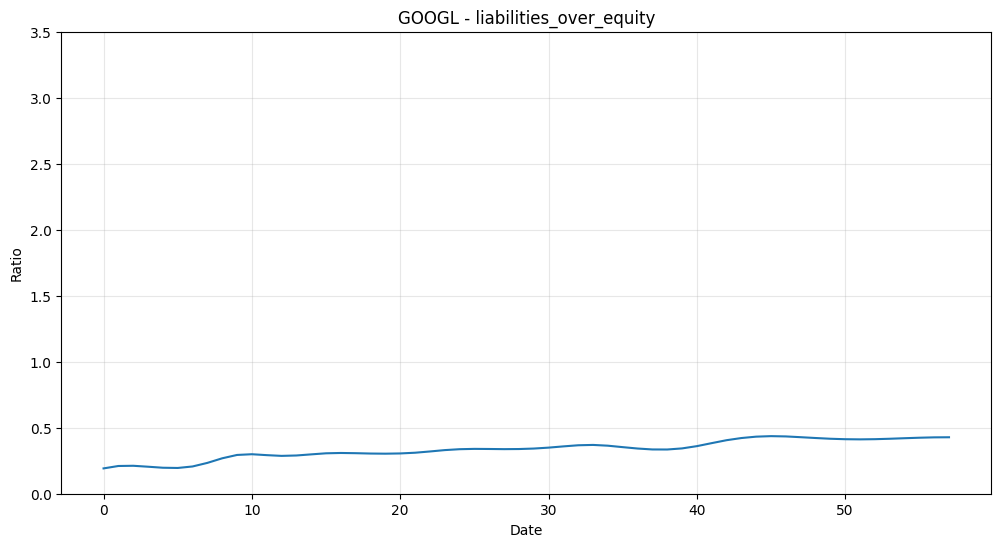

In [198]:
#correct
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, balance_sheet_df['liabilities_over_equity'])
plt.title(f'{stock} - liabilities_over_equity')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=0, top=3.5)
plt.grid(True, alpha=0.3)
plt.show()

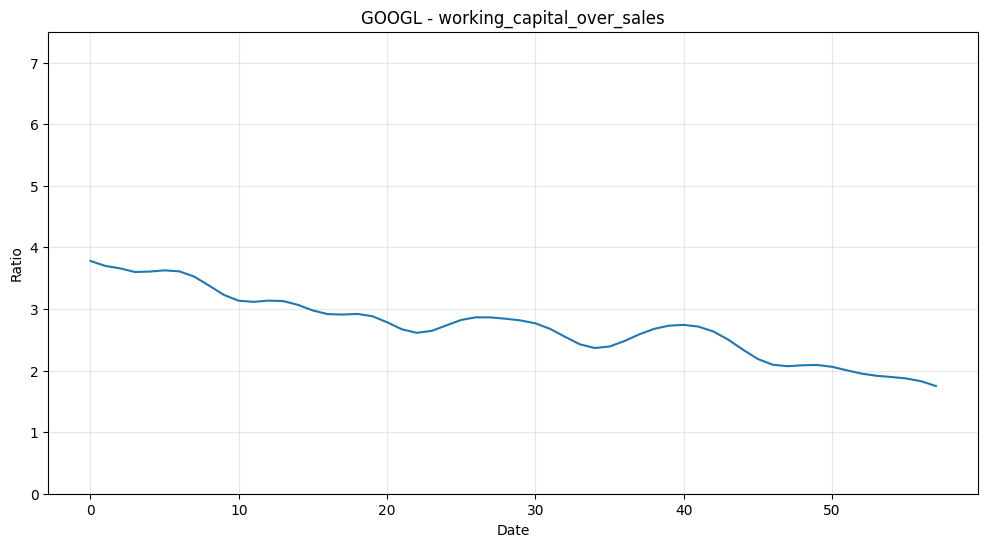

In [199]:
#correct but the first little bit is cut off on the papers graph
#still not sure if correct
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, bs_raw['working_capital_over_sales'])
plt.title(f'{stock} - working_capital_over_sales')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=0, top=7.5)
plt.grid(True, alpha=0.3)
plt.show()

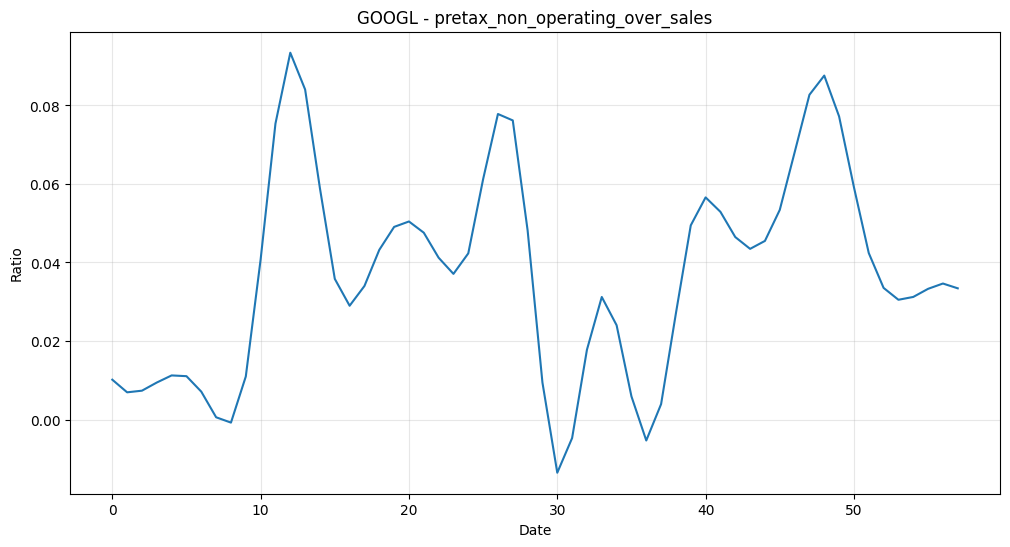

In [200]:
#not even close
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, income_df['pretax_non_operating_over_sales'])
plt.title(f'{stock} - pretax_non_operating_over_sales')
plt.xlabel('Date')
plt.ylabel('Ratio')
#plt.ylim(bottom=-0.05, top=0.10)
plt.grid(True, alpha=0.3)
plt.show()

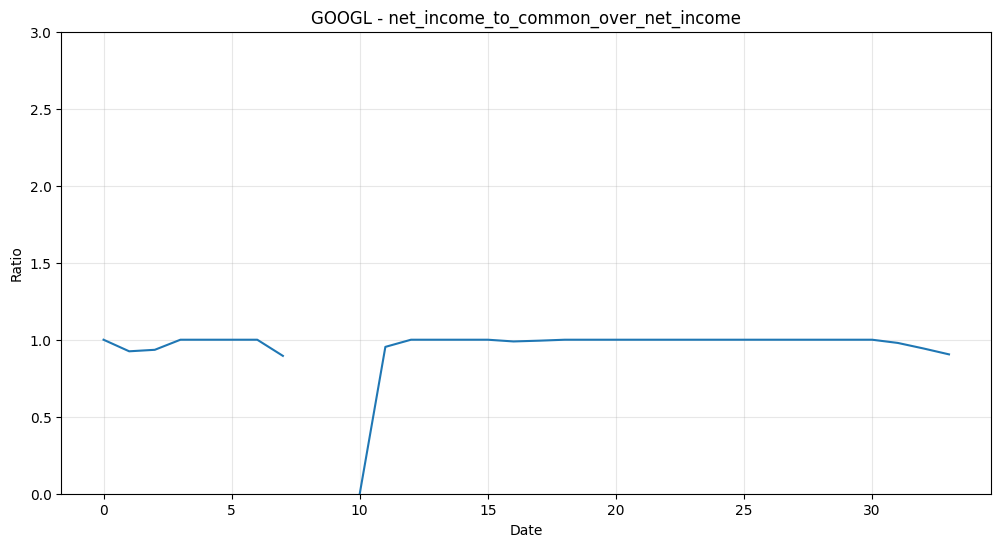

In [201]:
#not close
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, income_df['net_income_to_common_over_net_income'])
plt.title(f'{stock} - net_income_to_common_over_net_income')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=0, top=3)
plt.grid(True, alpha=0.3)
plt.show()

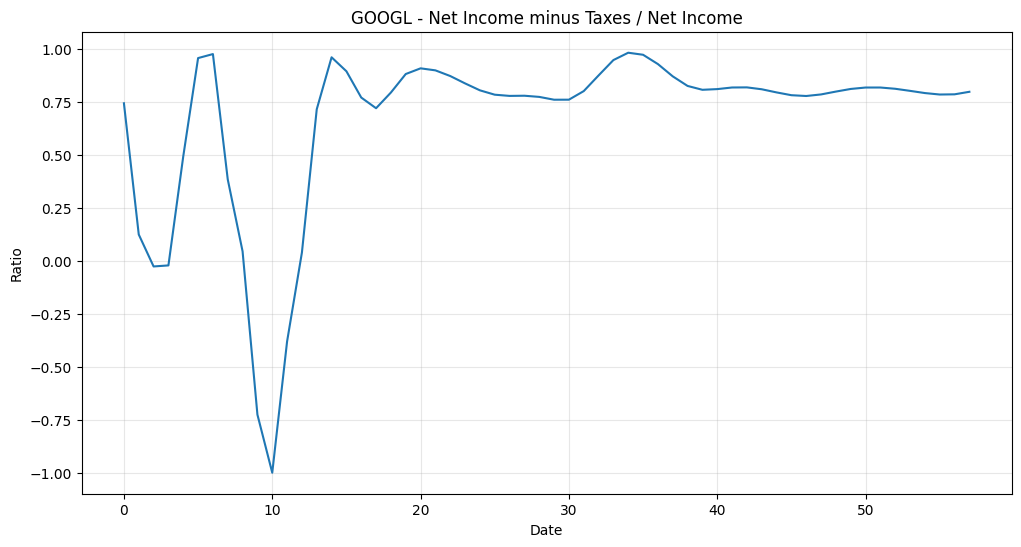

In [202]:
#close accept for first dip
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, income_df['net_income_minus_taxes_over_net_income'])
plt.title(f'{stock} - Net Income minus Taxes / Net Income')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.grid(True, alpha=0.3)
plt.show()

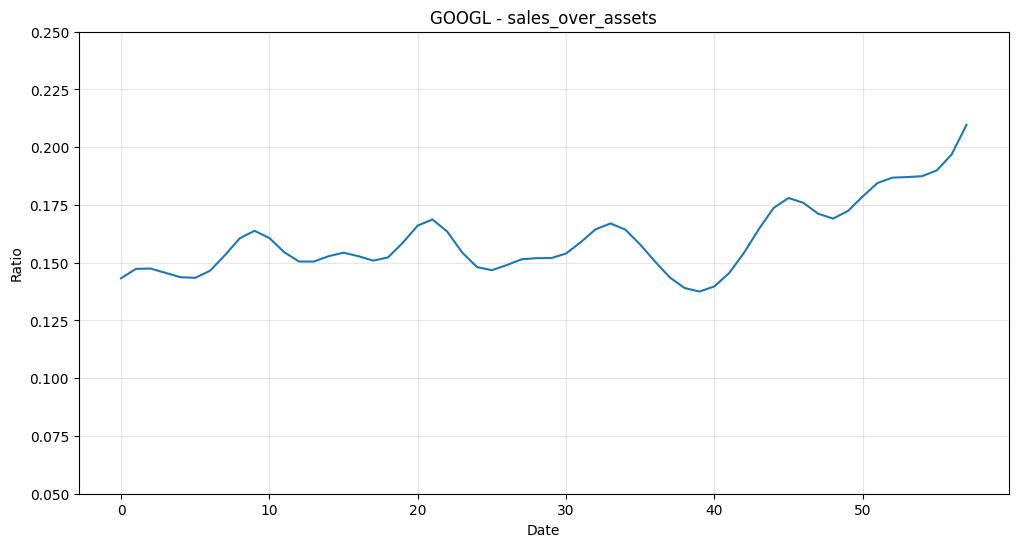

In [203]:
#good
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, income_df['sales_over_assets'])
plt.title(f'{stock} - sales_over_assets')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=0.05, top=0.25)
plt.grid(True, alpha=0.3)
plt.show()

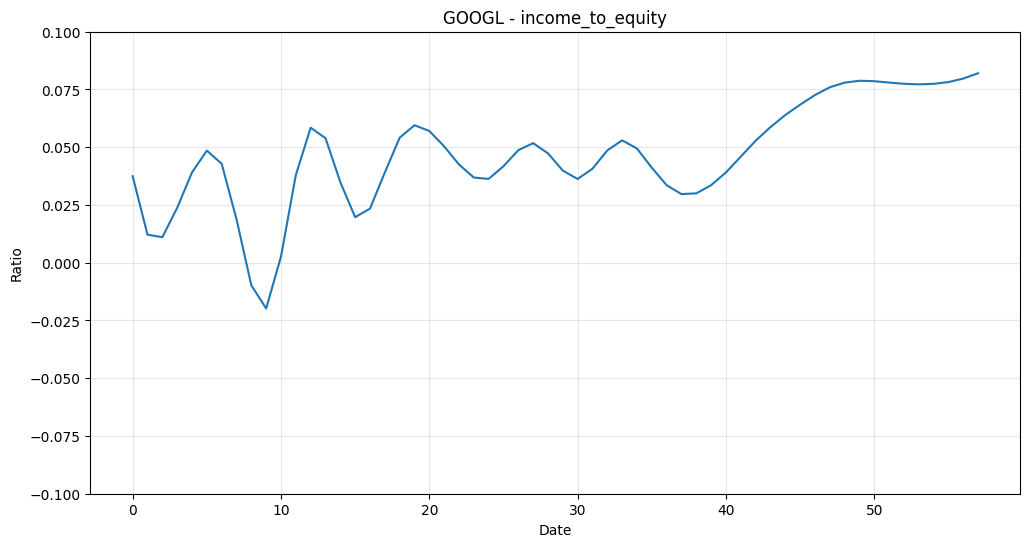

In [204]:
#good but needs smoothing?
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, income_df['income_to_equity'])
plt.title(f'{stock} - income_to_equity')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=-.1, top=0.1)
plt.grid(True, alpha=0.3)
plt.show()

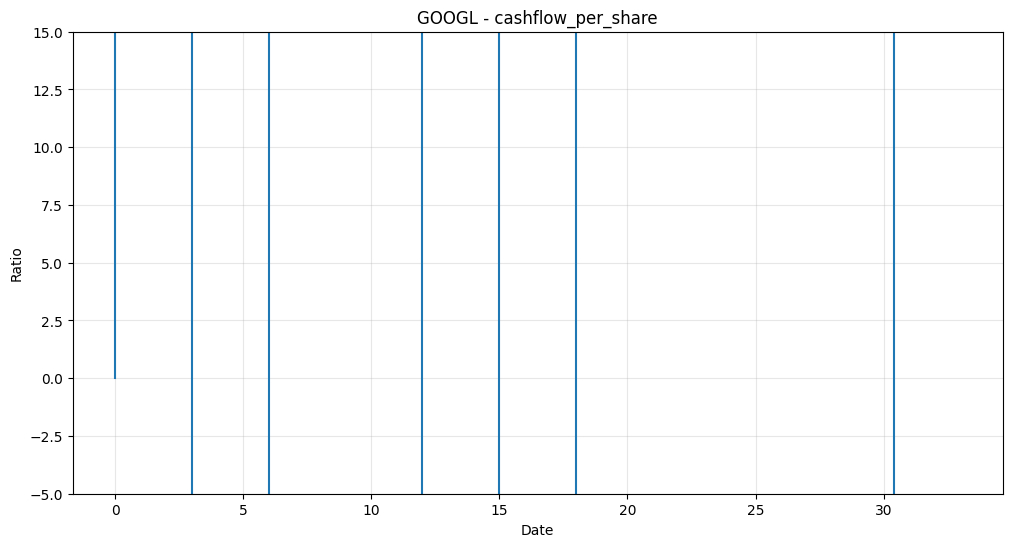

In [205]:
#completly wrong
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, cashflow_df['dividendPayout'])
plt.title(f'{stock} - cashflow_per_share')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=-5, top=15)
plt.grid(True, alpha=0.3)
plt.show()

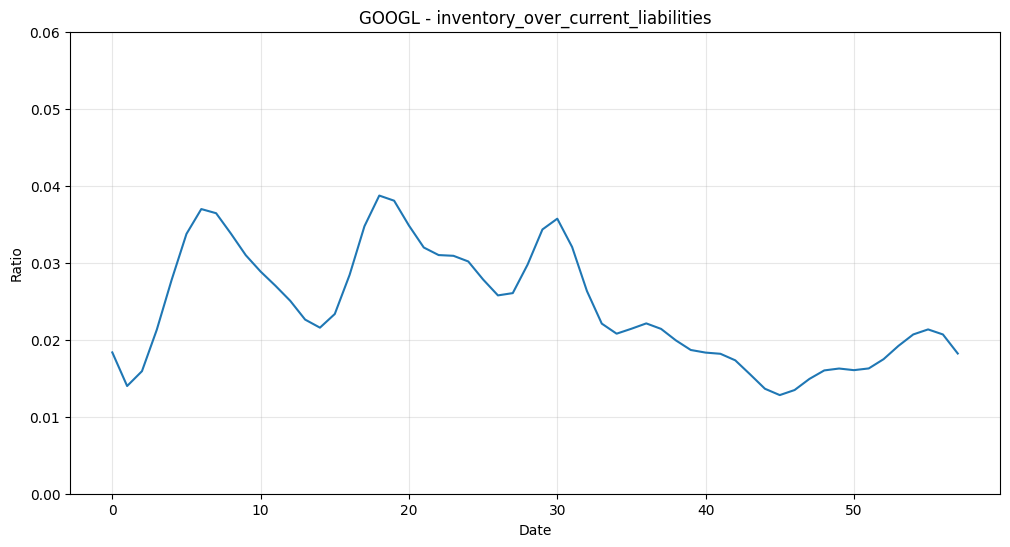

In [206]:
#very close
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, balance_sheet_df['inventory_over_current_liabilities'])
plt.title(f'{stock} - inventory_over_current_liabilities')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=0.00, top=0.06)
plt.grid(True, alpha=0.3)
plt.show()

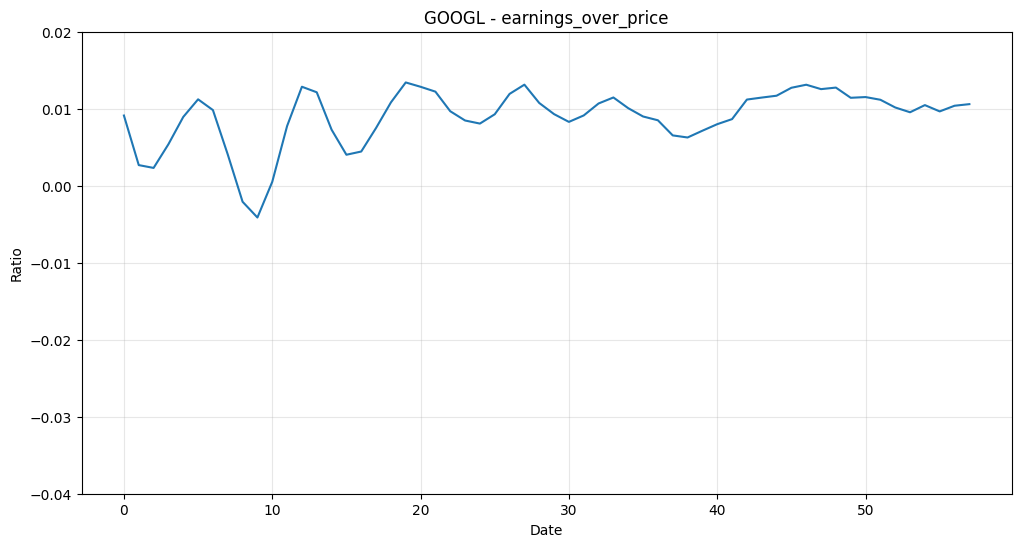

In [207]:
#correct
plt.figure(figsize=(12, 6))
plt.plot(income_df.index, income_df['earnings_over_price'])
plt.title(f'{stock} - earnings_over_price')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.ylim(bottom=-.04, top=0.02)
plt.grid(True, alpha=0.3)
plt.show()

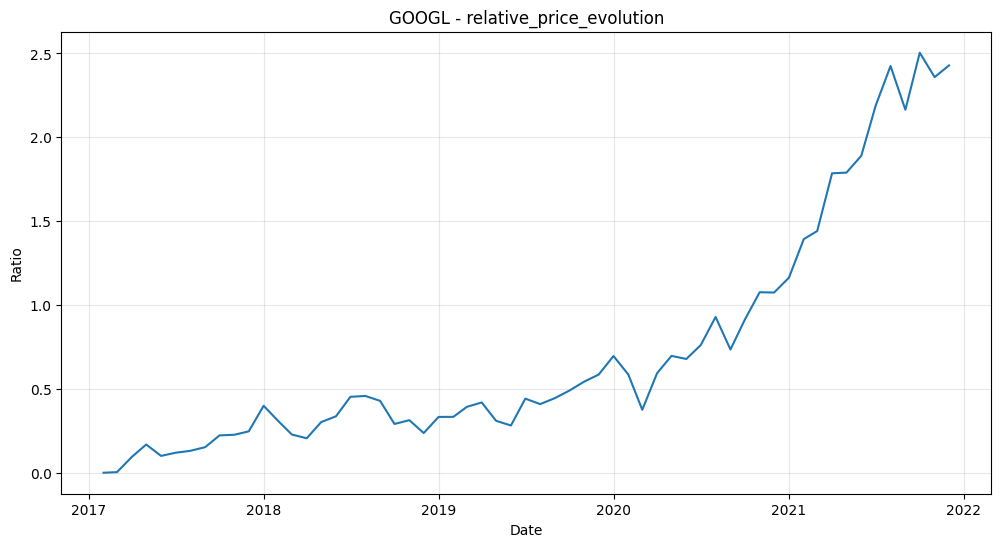

In [208]:
#good
plt.figure(figsize=(12, 6))
plt.plot(price_df['fiscalDateEnding'], price_df['relative_price_evolution'])
plt.title(f'{stock} - relative_price_evolution')
plt.xlabel('Date')
plt.ylabel('Ratio')
# plt.ylim(bottom=0, top=1) # Removed the y-axis limit to show full range
plt.grid(True, alpha=0.3)
plt.show()